## Chatbot Memory Optimization

Boilerplate Code

In [1]:
import langchain 
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
Groq_api_key=os.getenv("GROQ_API_KEY")

llm=ChatGroq(
    api_key=Groq_api_key,
    model="openai/gpt-oss-120b",
    temperature=0.2
    )



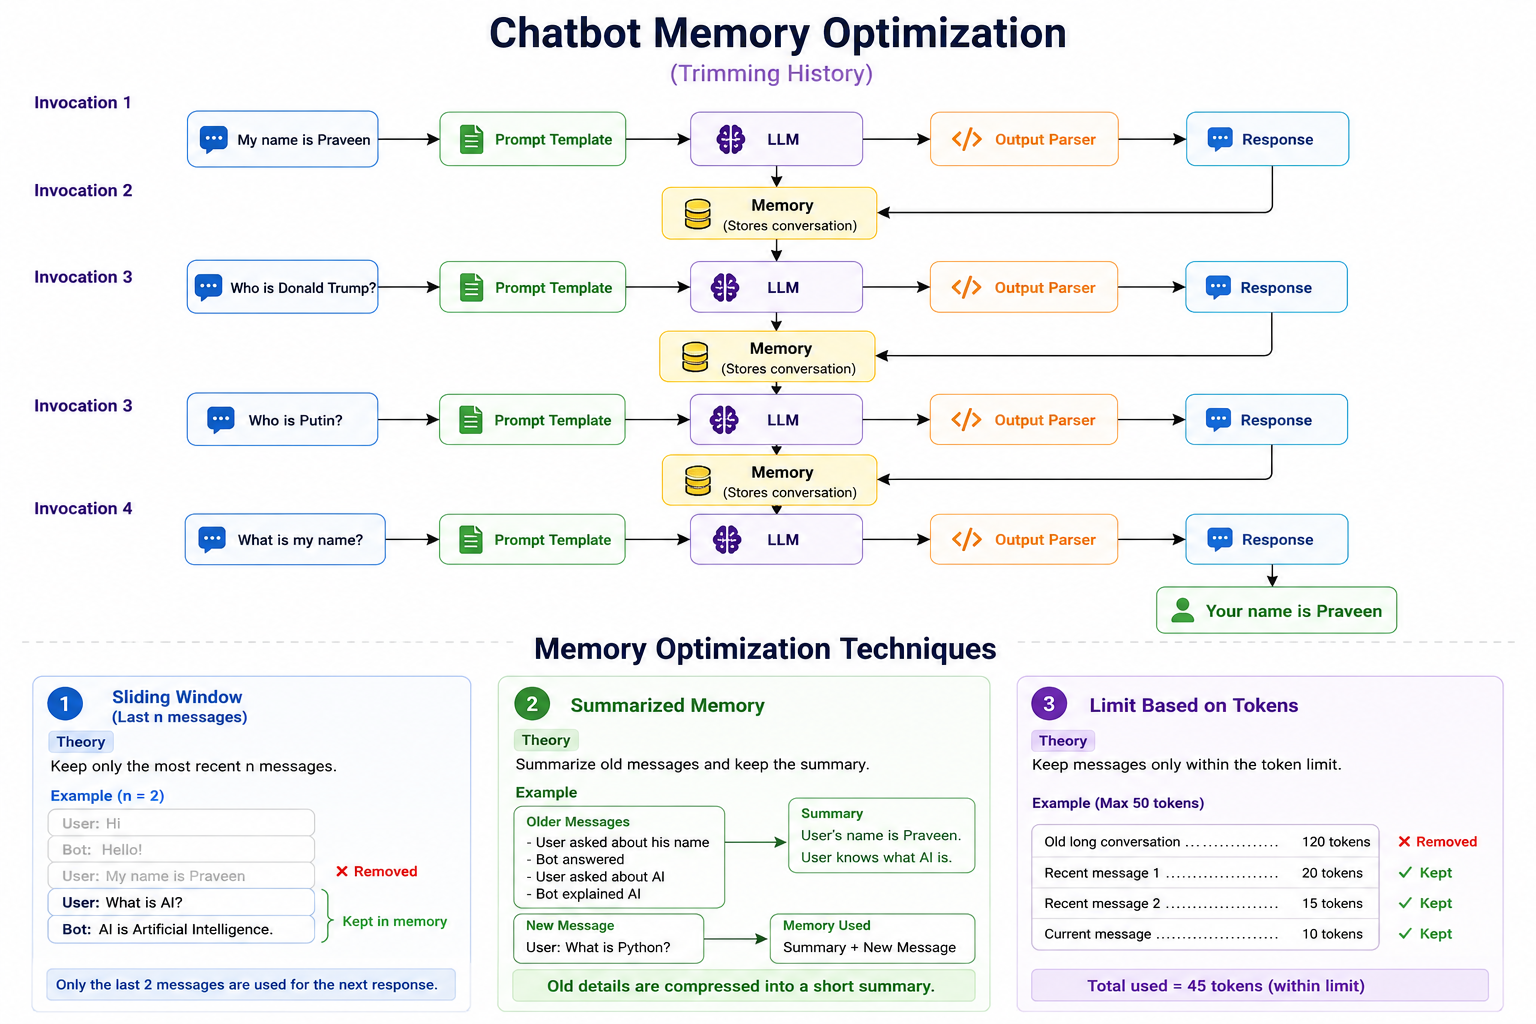

## Sliding Window - last n messages techique

Just To knowing  the manual trimming of history

In [5]:
from langchain_core.messages import HumanMessage ,AIMessage
from langchain_core.prompts import  MessagesPlaceholder
from langchain_community.chat_message_histories import ChatMessageHistory


prompt = ChatPromptTemplate.from_messages([
    ('system','You are a helpful assistant . Answer all the questions briefly and concisely .'),
    MessagesPlaceholder('history'),
    ('human','{input}')
])

chain=prompt | llm | StrOutputParser()

conversation ={}  # {session1:[],session2:[]}

def chat_with_bot(payload):
    input=payload['input']
    session_id=payload['session_id']

    if session_id not in conversation:
        conversation[session_id]=ChatMessageHistory()

    history=conversation[session_id]

    # changes from existing  LCEL -> multi session is  [when we change this value we can gain more context for the conversation but it will increase the cost of the API call]
    history.messages=history.messages[-8:]

    history.add_user_message(input)
    response=chain.invoke({"input":input,"history":history.messages})
    history.add_ai_message(response)
    print(f"history messages length: {len(history.messages)}")
    return response

res = chat_with_bot({"input": "I am Joe", "session_id": "user1"})
print(conversation, "\n", res, "\n")

res = chat_with_bot({"input": "I am from Coimbatore?", "session_id": "user1"})
print(conversation, "\n", res, "\n")

res = chat_with_bot({"input": "Where is it located?", "session_id": "user1"})
print(conversation, "\n", res, "\n")

res = chat_with_bot({"input": "What is my name?", "session_id": "user1"})
print(conversation, "\n", res, "\n")



history messages length: 2
{'user1': InMemoryChatMessageHistory(messages=[HumanMessage(content='I am Joe', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Joe!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])])} 
 Nice to meet you, Joe! 

history messages length: 4
{'user1': InMemoryChatMessageHistory(messages=[HumanMessage(content='I am Joe', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Joe!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='I am from Coimbatore?', additional_kwargs={}, response_metadata={}), AIMessage(content="That's cool—Coimbatore is known for its pleasant climate and vibrant textile industry!", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])])} 
 That's cool—Coimbatore is known for its pleasant climate and vibrant textile industry! 

history messages length: 6
{'user1': I

This above methode is  for custom method but while we develop this for production , we can go with **RunnableWithMessageHistory**

### trimming history by RunnableWithMessageHistory

In [ ]:
from collections import deque
from langchain_core.chat_history import BaseChatMessageHistory

from langchain_core.messages import HumanMessage ,AIMessage
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate , MessagesPlaceholder
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables import RunnableWithMessageHistory

prompt = ChatPromptTemplate.from_messages([
    ('system','You are a helpful assistant . Answer all the questions briefly and concisely .'),
    MessagesPlaceholder('history'),
    ('human',"{input}")
])

chain=prompt | llm | StrOutputParser()

store ={}  # {session1:[],session2:[]}

class WindowedChatMessageHistory(BaseChatMessageHistory):
    def __init__(self, k: int = 2):
        self._messages = deque(maxlen=k*2)     
        
    @property
    def messages(self):
        return list(self._messages)
        
    def add_message(self, message: str) -> None:
        self._messages.append(message)
        
    def clear(self):
        self._messages.clear()


def get_session_history(session_id):
    if session_id not in store:
        store[session_id]=WindowedChatMessageHistory(k=4)  # by change this k value to adjust the number of messages to keep in the history for each session
    return store[session_id]

chain_with_history=RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history"
)

res = chain_with_history.invoke(
    {"input": "My name is Sandy."},
    config={"configurable": {"session_id": "user1"}}
)
print(res, "\n")

res = chain_with_history.invoke(
    {"input": "what is oldest laguage in india?"},
    config={"configurable": {"session_id": "user1"}}
)
print(res, "\n")

res = chain_with_history.invoke(
    {"input": "Who is MGR?"},
    config={"configurable": {"session_id": "user1"}}
)
print(res, "\n")

res = chain_with_history.invoke(
    {"input": "What is my name?"},
    config={"configurable": {"session_id": "user1"}}
)
print(res, "\n")


C:\Users\smart\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3577: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


Nice to meet you, Sandy! How can I assist you today? 

The oldest recorded language of India is **Sanskrit**, whose earliest texts (the Vedas) date back to around 1500  BCE.  
Among living languages, **Tamil** holds the title of the oldest continuously spoken language, with literary works dating from the early centuries CE. 

M. G. Ramachandran (commonly known as **MGR**) (1917–1987) was a celebrated Indian film actor and politician. He starred in hundreds of Tamil movies, became a cultural icon, and later founded the AIADMK party, serving as the Chief Minister of Tamil Nadu from 1977 until his death in 1987. 

Your name is Sandy. 



## Summarized Method

In [25]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage


class SummarizedHistory:

    def __init__(self):
        self.summary = "The conversation is empty."

    def update(self, user_msg, ai_msg):
        # Summarize old summary + new turn
        summarize_prompt = ChatPromptTemplate.from_messages(
            [
                ("system", "Summarize the conversation so far briefly."),
                ("human","Previous summary:\n{summary}\n\nNew exchange:\nUser: {user}\nAI: {ai}\n\nUpdated summary:")
            ]
        )
        chain = summarize_prompt | llm | StrOutputParser()
        res = chain.invoke(
            {"summary": self.summary, "user": user_msg, "ai": ai_msg}
        )
        self.summary = res
prompt_template = ChatPromptTemplate.from_messages([
    ('system', 'You are a helpful assistant. Answer all my questions shortly and briefly from now on.'),
    ('system', 'Here is the previous conversation summary for your reference: {summary}'),
    ('human', '{input}')
])

chain = prompt_template | llm | StrOutputParser()

# store = {session_id: summary, session_id: summary}
store = {}

# Create / get history per session
def get_session(session_id):
    if session_id not in store:
        store[session_id] = SummarizedHistory()
    return store[session_id]

# Example use
session = get_session("abc123")





In [27]:
user_input = "i am sandy. i am a musician."
ai_output = chain.invoke({"input": user_input, "summary": session.summary})
session.update(user_input, ai_output)
print("AI:", ai_output, "\n", "Summary:", session.summary, "\n")

user_input = "Remind me what i just said"
ai_output = chain.invoke({"input": user_input, "summary": session.summary})
session.update(user_input, ai_output)
print("AI:", ai_output, "\n", "Summary:", session.summary, "\n")

AI: Nice to meet you, Sandy! What kind of music do you play? 
 Summary: **Updated Summary:**  
Praveen introduced himself and mentioned that he likes Python. The assistant responded warmly, noting Python’s greatness and asking what Praveen is working on. Praveen then asked the assistant to remind him what he had just said, and the assistant replied that he had said he’s Praveen and that he likes Python.  

Later, the user said, “I am Sandy. I am a musician.” The assistant replied, “Nice to meet you, Sandy! What kind of music do you play?” 

AI: You said, “I am Sandy. I am a musician.” 
 Summary: **Updated Summary:**  
- Praveen introduced himself and said he likes Python.  
- The assistant welcomed him, praised Python, and asked about his projects.  
- Praveen asked the assistant to repeat what he had just said; the assistant correctly recalled Praveen’s introduction.  
- The user then switched personas, saying “I am Sandy. I am a musician.”  
- The assistant responded warmly, asking w